In [3]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
model   = joblib.load("models/dengue_model.pkl")
encoder = joblib.load("models/encoder.pkl")



In [6]:
FEATURES = [
    # area
    "area_encoded",
    # current week weather
    "avg_temperature_2m_mean",
    "avg_temperature_2m_max",
    "avg_precipitation_sum",
    "avg_relative_humidity_2m_mean",
    "temp_range",
    "heat_humidity_index",
    # seasonal cycle
    "week_sin",
    "week_cos",
    # case lag features
    "cases_lag1",
    "cases_lag2",
    "cases_lag3",
    "cases_roll_mean4",
    "cases_trend",
    # previous week weather
    "temp_lag1",
    "precip_lag1",
    "humidity_lag1",
]

In [7]:
test_df = pd.read_csv("data/test.csv")

# grab the very last week for each area — that's our prediction input
last_week_df = test_df.sort_values("week").groupby("moh_area").tail(1)

X = last_week_df[FEATURES]

preds = np.expm1(model.predict(X.values)).clip(0)
preds = np.round(preds).astype(int)

results_df = pd.DataFrame({
    "moh_area"       : last_week_df["moh_area"].values,
    "predicted_cases": preds
}).sort_values("predicted_cases", ascending=False).reset_index(drop=True)

print(results_df.head(10).to_string(index=False))

      moh_area  predicted_cases
 MOH-Gothatuwa               47
  MOH-Kaduwela               22
  MOH-Homagama               21
MOH-Maharagama               21
   MOH-Gampaha               21
    MOH-D3-CMC               20
  MOH-Kelaniya               18
    MOH-Ja-Ela               18
   MOH-Wattala               18
    MOH-D4-CMC               16


In [9]:
print(f"Top 10 highest predicted areas:")
print(results_df.head(10).to_string(index=False))

print(f"\nAverage : {results_df['predicted_cases'].mean():.1f}")
print(f"Max     : {results_df['predicted_cases'].max()}")

Top 10 highest predicted areas:
      moh_area  predicted_cases
 MOH-Gothatuwa               47
  MOH-Kaduwela               22
  MOH-Homagama               21
MOH-Maharagama               21
   MOH-Gampaha               21
    MOH-D3-CMC               20
  MOH-Kelaniya               18
    MOH-Ja-Ela               18
   MOH-Wattala               18
    MOH-D4-CMC               16

Average : 3.0
Max     : 47


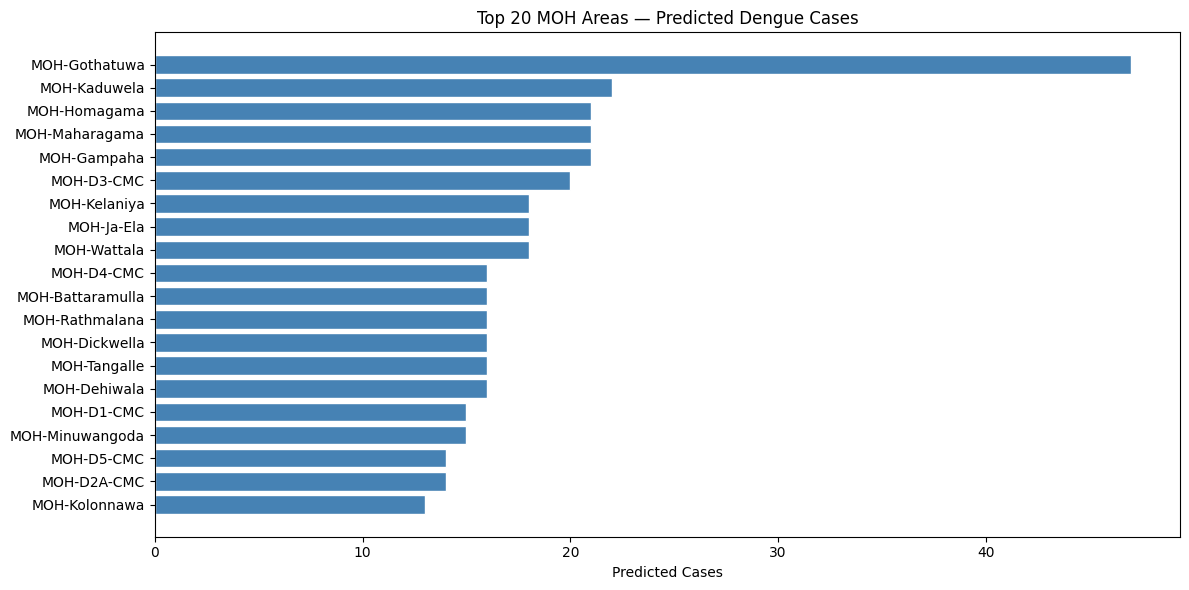

In [10]:
top20 = results_df.head(20)

plt.figure(figsize=(12, 6))
plt.barh(top20["moh_area"][::-1], top20["predicted_cases"][::-1],
         color="steelblue", edgecolor="white")
plt.xlabel("Predicted Cases")
plt.title("Top 20 MOH Areas — Predicted Dengue Cases")
plt.tight_layout()
plt.show()

In [12]:
os.makedirs("outputs", exist_ok=True)

results_df.to_csv("outputs/predictions.csv", index=False)

with open("outputs/predictions.json", "w") as f:
    json.dump(results_df.set_index("moh_area")["predicted_cases"].to_dict(), f, indent=4)

print("Saved outputs/predictions.csv")
print("Saved outputs/predictions.json")

Saved outputs/predictions.csv
Saved outputs/predictions.json
